In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

(101, 101)


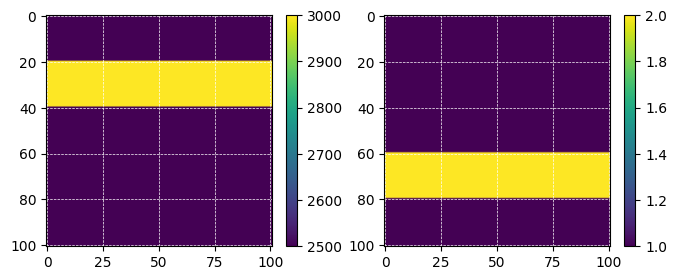

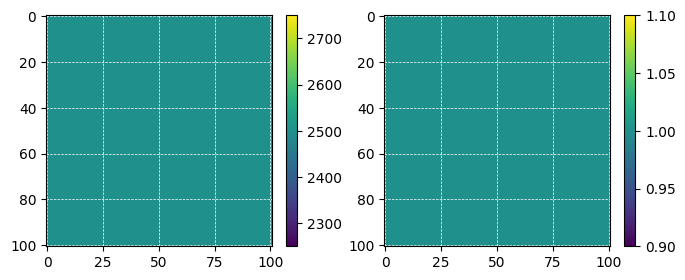

In [33]:
nz=101; nx=101
h=20  #500/20=25

vmin=2500; vmax=3000

nsnap=51; nzsnap=124; nxsnap=124

#5h=lambda=vmin/fmax
fmax=vmin/(5*h) #
fpeak=fmax/2.5  #10 Hz

#on time
dt=0.004
nt=500

ntr=100

#make model
vp=vmin*np.ones((nz,nx)); print(vp.shape)
vp[20:40,:]=vmax
vp.T.astype('float32').tofile('vp')

rho=np.ones((nz,nx))
rho[60:80,:]=2.
rho.T.astype('float32').tofile('rho')

!cat vp rho > true

#make model
vp=vmin*np.ones((nz,nx))
vp.T.astype('float32').tofile('vp')

rho=np.ones((nz,nx))
rho.T.astype('float32').tofile('rho')

!cat vp rho > homo

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('true',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('true',(2*nx,nz))[:,nx:])

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('homo',(2*nx,nz))[:,:nx])
plt.subplot(1,2,2); imshow(read('homo',(2*nx,nz))[:,nx:])

In [35]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/RTM',setup='setup',np=1,nthreads=8,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

In [41]:
!cat setup_default

MODEL_SIZE              '101 101 1'
MODEL_SPACING            '20 20 1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho'
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '20  20 0'
FR                      '20  20 0'
DR                      '0   20  0'
NR                      100

IF_HICKS                F

SCOMP                   p
RCOMP                   p #'p vz'

NT               500
DT               0.004


FPEAK            10
WAVELET_TYPE        'ricker'


#SNAPSHOT      'p'


## for RTM ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'

JOB           imaging

IF_USE_CHECKPOINT   F



## data

In [28]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2323456 Jun 26 13:54 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 14:03:01
System timezone: +08:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.4

In [30]:
!cp setup_default setup
!echo "FILE_MODEL  homo" >> setup
!echo "DIR_OUT     results_homo" >> setup
run(app='../../exe/fwd_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2323456 Jun 26 13:54 ../../exe/fwd_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 14:46:04
System timezone: +08:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_homo
 Output directory:results_homo/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0

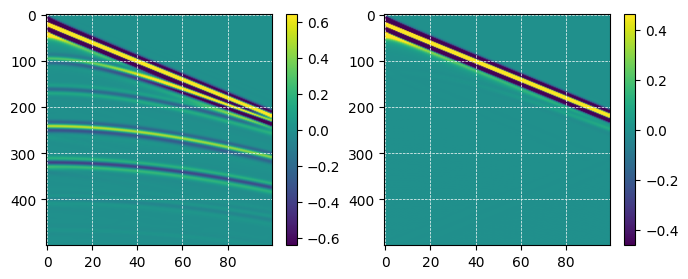

In [39]:
## plot
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read_su('./results_obs/Ru_Shot0001.su') ,perc=95)
plt.subplot(1,2,2); imshow(read_su('./results_homo/Ru_Shot0001.su'),perc=95)

In [59]:
!cp setup_default setup
!echo "FILE_MODEL  homo" >> setup
!echo "DIR_OUT     results_rtm" >> setup
run(app='../../exe/rtm_AC_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           8
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/06_ImageGathers
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2555672 Jun 26 15:25 ../../exe/rtm_AC_FDSG_O4_
 Git Commit: 3bc2a52
 Git Branch: RTM
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2025
System time: 15:25:11
System timezone: +08:00
                        
       WELCOME TO SeisJIMU RTM        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_rtm
 Output directory:results_rtm/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.4

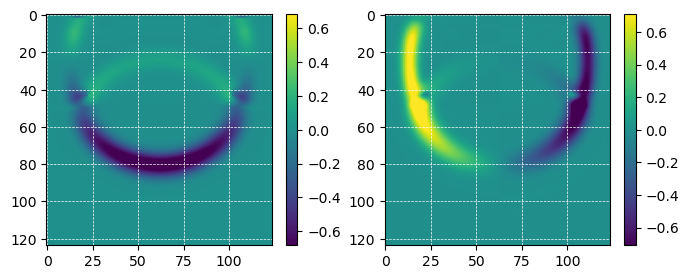

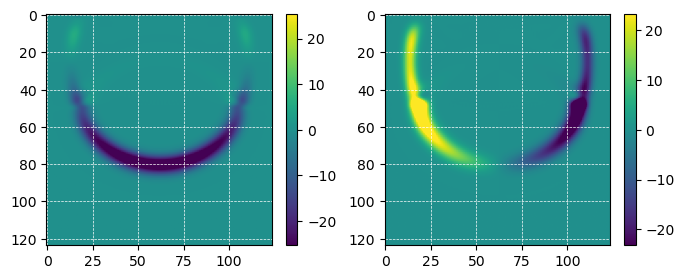

In [16]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(E*dph_dz,perc=98)
plt.subplot(1,2,2); imshow(E*dph_dx,perc=98)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(E**2*dph_dz,perc=98)
plt.subplot(1,2,2); imshow(E**2*dph_dx,perc=98)